# QED-C Application-Oriented Benchmarks - IQM
The notebook demonstrates problem generation, execution, and analysis of one of the many supported application-oriented benchmarks on IQM.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
min_qubits=2
max_qubits=10
skip_qubits=1
max_circuits=3
num_shots=1000

In [2]:
# QED-C
from hidden_shift import hs_benchmark
from _common import metrics
from _common.qiskit import execute as ex

# Qiskit
from qiskit import QuantumCircuit, transpile

# IQM
from iqm.qiskit_iqm import IQMProvider

## Part 1: Problem Generation

Utilizing the new **_get_circuits_** flag in the architecture, we can supress execution and obtain only the problem generation components of interest.

In [3]:
circuits, metadata = hs_benchmark.run(
    min_qubits=min_qubits, 
    max_qubits=max_qubits, 
    skip_qubits=skip_qubits,
    max_circuits=max_circuits, 
    num_shots=num_shots, 
    get_circuits=True
)

print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}")

Hidden Shift Benchmark Program - Qiskit
... execution starting at Apr 23, 2026 16:44:58 UTC
************
Creating [3] circuits with num_qubits = 2
************
Creating [3] circuits with num_qubits = 4
************
Creating [3] circuits with num_qubits = 6
************
Creating [3] circuits with num_qubits = 8
************
Creating [3] circuits with num_qubits = 10
************
Returning circuits and circuit information

Circuits:
{'2': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x161519f40>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1606f79e0>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16152bfb0>}, '4': {'2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613cfa70>, '4': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16152b320>, '5': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613e44a0>}, '6': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613fd670>, '36': <qiskit.circu

### The Circuits and Metadata
Note the format of the outputs:
- **circuits**: dict[str, dict[str, QuantumCircuit]] 
- **metadata**: dict[str, dict[str, dict[str, float]] | str]

Where 
1. The **first dictionary's key** represents the **number of qubits** for the group. In _metadata_, it may also serve as the subtitle.
2. The **second dictionary's key** represents the **unique identifier** for a circuit in the group. This may be a secret string for Bernstein-Vazirani, theta value for Phase-Estimation, and so on. Benchmark specific documentation can be found in our repository.
3. The **third dictionary's key** represents the **metric being stored** in _metadata_. (There is no third dictionary in _circuits_).

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

In [4]:
# Remove the subtitle key for iterating purposes.
metadata.pop("subtitle", None)

# Copy any metadata from creation (i.e. create_time). This can be excluded if it's not of interest.
metrics.circuit_metrics = metadata

# Create a flat list of circuits.
circuit_identifiers = []
flat_circuits = []
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        circuit_identifiers.append((num_qubits, circuit_id))
        flat_circuits.append(circuits[num_qubits][circuit_id])

        # Optionally compute additional circuit properties (depth, etc.) and store to metrics.
        ex.compute_and_store_circuit_info(
            circuits[num_qubits][circuit_id],
            str(num_qubits),
            str(circuit_id),
            do_transpile_metrics=True,
            use_normalized_depth=True,
        )

print(f"Flat Circuits: \n{flat_circuits}\n")
print(f"Additional Metrics: \n{metrics.circuit_metrics}")

Flat Circuits: 
[<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x161519f40>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1606f79e0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16152bfb0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613cfa70>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16152b320>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613e44a0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613fd670>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x161529580>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16151ad20>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x161528440>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1615aff80>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1613cf0e0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x16152a6c0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x1615af0e0>, <qi

## Running Circuits

We execute the flat circuits on IQM. 

Configure the cell below with the target quantum computer and your IQM Resonance Token. 

In [5]:
iqm_server_url = "https://resonance.meetiqm.com"
quantum_computer = "sirius"
IQM_Token = "AN2qaA2AKER47Hmnh4E5sM518STqDoliZkSuQZIZEjMBnbsFImZ/I6qsb4IBf4tE" #"<IQM Resonance TOKEN>"

In [6]:
provider = IQMProvider(iqm_server_url, quantum_computer=quantum_computer, token=IQM_Token)
backend = provider.get_backend()

transpiled_circuit = transpile(flat_circuits, backend=backend)
job = backend.run(transpiled_circuit, shots=num_shots)

In [7]:
result = job.result()
print(result.get_counts())

[{'01': 907, '11': 31, '00': 54, '10': 8}, {'10': 856, '00': 84, '01': 27, '11': 33}, {'11': 864, '10': 45, '01': 70, '00': 21}, {'0010': 732, '0011': 41, '0000': 63, '1110': 19, '0111': 2, '1101': 4, '1010': 45, '0110': 43, '0001': 23, '1100': 2, '1000': 10, '1001': 1, '0101': 3, '0100': 7, '1111': 2, '1011': 3}, {'0100': 736, '0000': 54, '1100': 53, '0110': 42, '1001': 4, '0011': 8, '0101': 45, '0111': 20, '1000': 18, '0001': 3, '1101': 5, '0010': 4, '1111': 4, '1010': 2, '1110': 1, '1011': 1}, {'1001': 19, '0101': 760, '1101': 51, '0000': 4, '0111': 28, '1100': 5, '0100': 41, '0001': 65, '0110': 14, '0010': 2, '1110': 4, '1011': 2, '1111': 3, '0011': 1, '1010': 1}, {'000101': 46, '110000': 1, '000001': 637, '100001': 38, '010001': 44, '001001': 35, '000011': 39, '100011': 2, '110001': 35, '000010': 22, '001101': 13, '000000': 42, '010000': 4, '010101': 6, '110010': 2, '111001': 2, '011001': 2, '101011': 1, '001000': 2, '100000': 1, '001011': 3, '010110': 2, '000100': 3, '000111': 2,

## Part 3: Analysis and Results
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [8]:
class CountsWrapper:
        """
        A wrapper class to enable support with QED-C's method to analyze results.
        """

        def __init__(self, counts: dict[str, int]):
            self.counts = counts

        def get_counts(self, _):
            return self.counts
            
# Iterate over each submitted circuit using the circuit identifiers:
for curr_idx, (num_qubits, circuit_id) in enumerate(circuit_identifiers):
    # Wrap the counts
    counts = result.get_counts(curr_idx)
    result_obj = CountsWrapper(counts)
    
    # Compute the fidelity
    _, fidelity = hs_benchmark.analyze_and_print_result(
        None, 
        result_obj, 
        int(num_qubits), 
        num_shots, 
        s_int=int(circuit_id),
    )
    
    # Store the fidelity.
    metrics.store_metric(num_qubits, circuit_id, "fidelity", fidelity)

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

In [9]:
# Compute statistics for metrics.
metrics.aggregate_metrics()

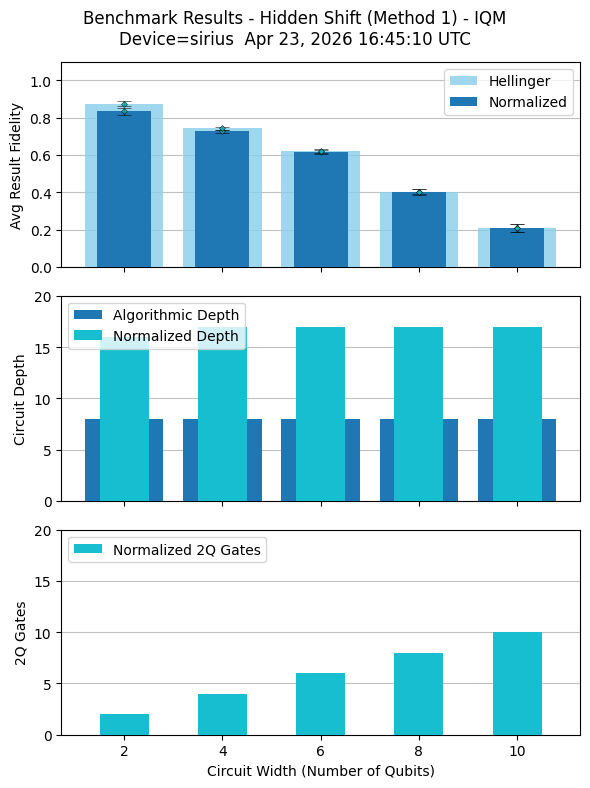

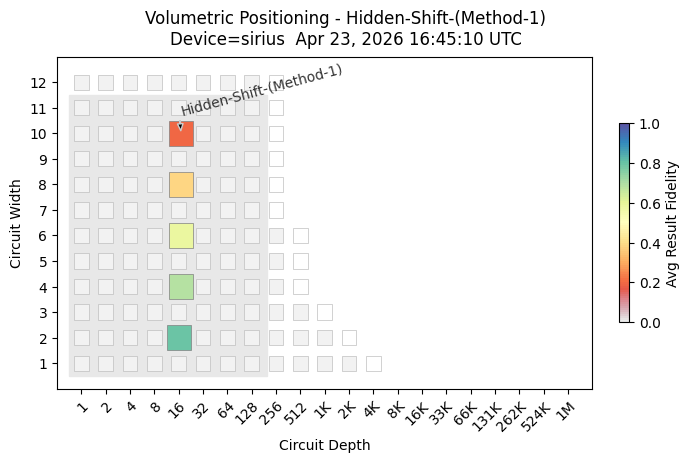

In [10]:
# Set information for plot titles.
benchmark_name = "Hidden Shift"
provider_name = "IQM"
device_name = quantum_computer

# Set plot titles.
benchmark_title = f"{benchmark_name} (Method 1)"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)

Number of Qubits: 2


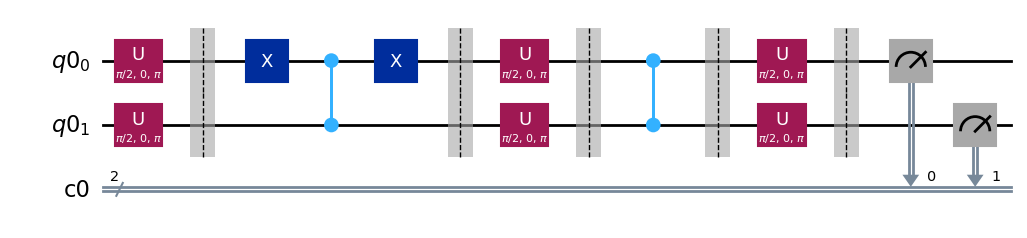

Number of Qubits: 4


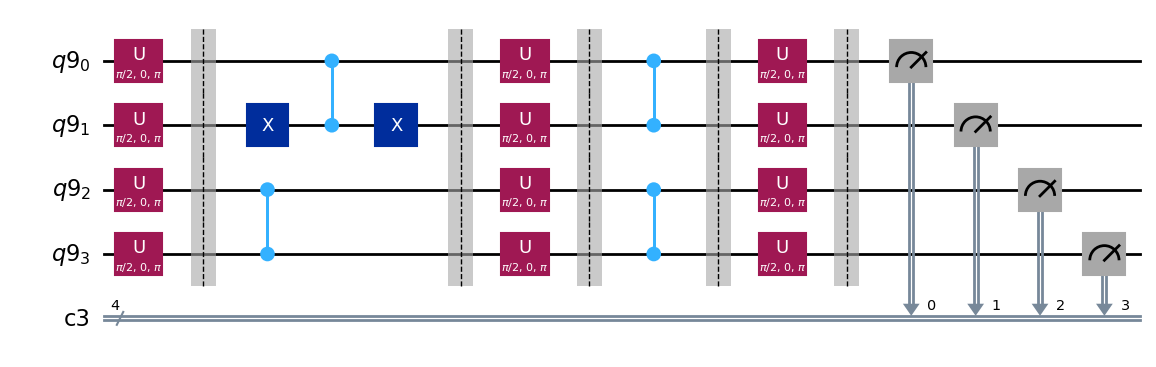

Number of Qubits: 6


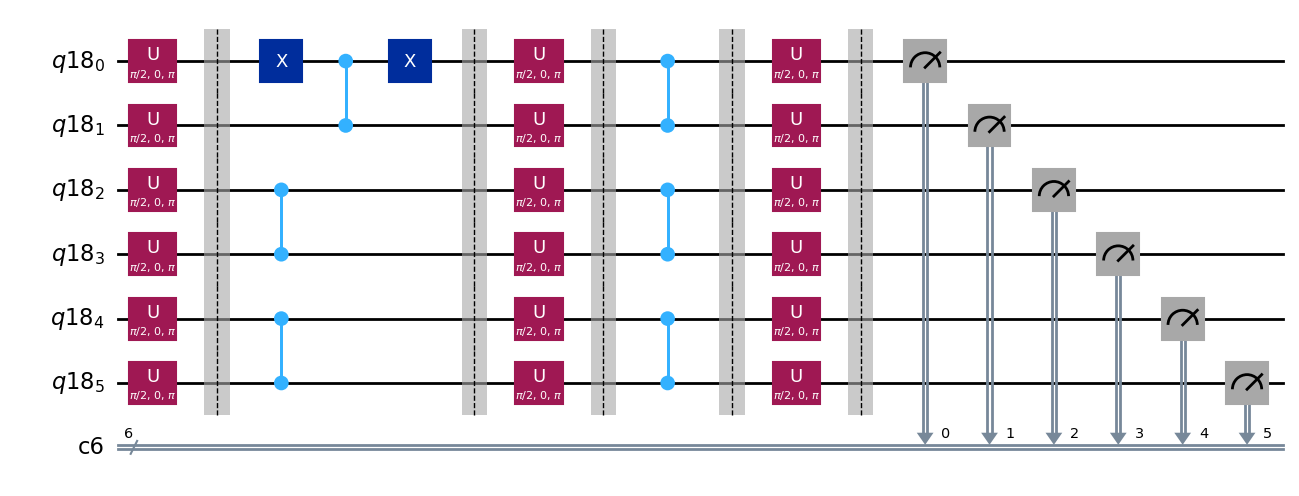

Number of Qubits: 8


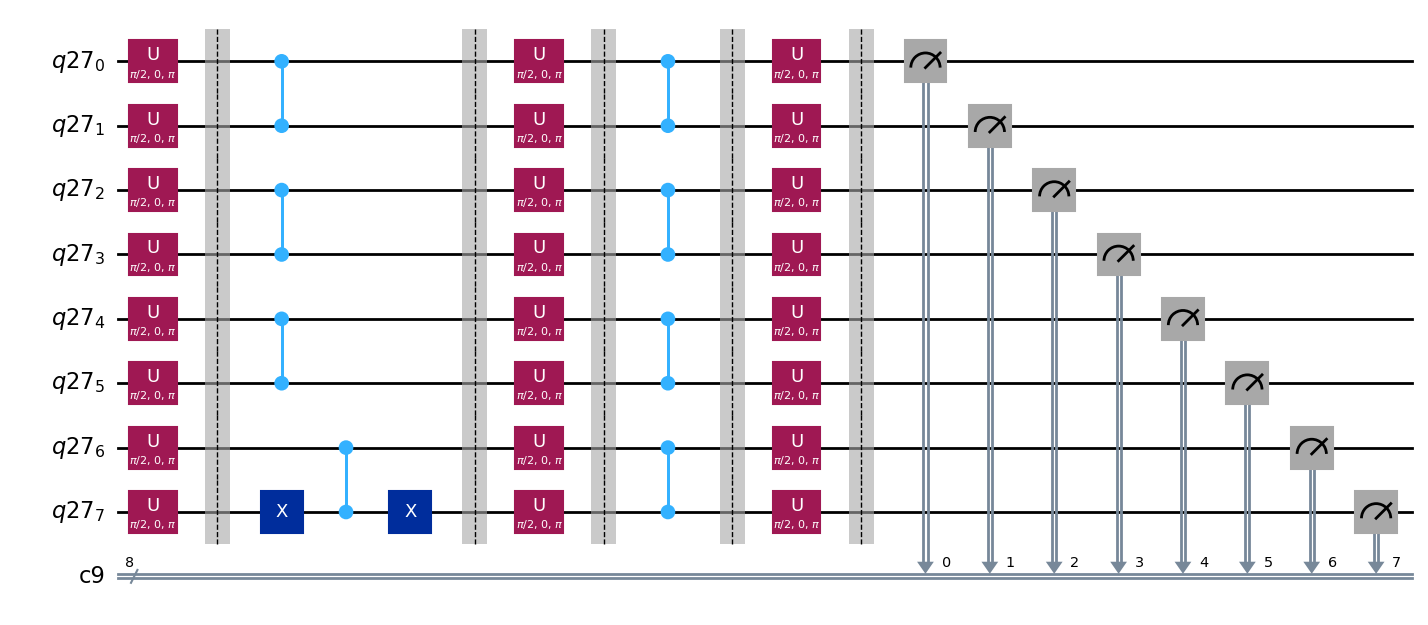

Number of Qubits: 10


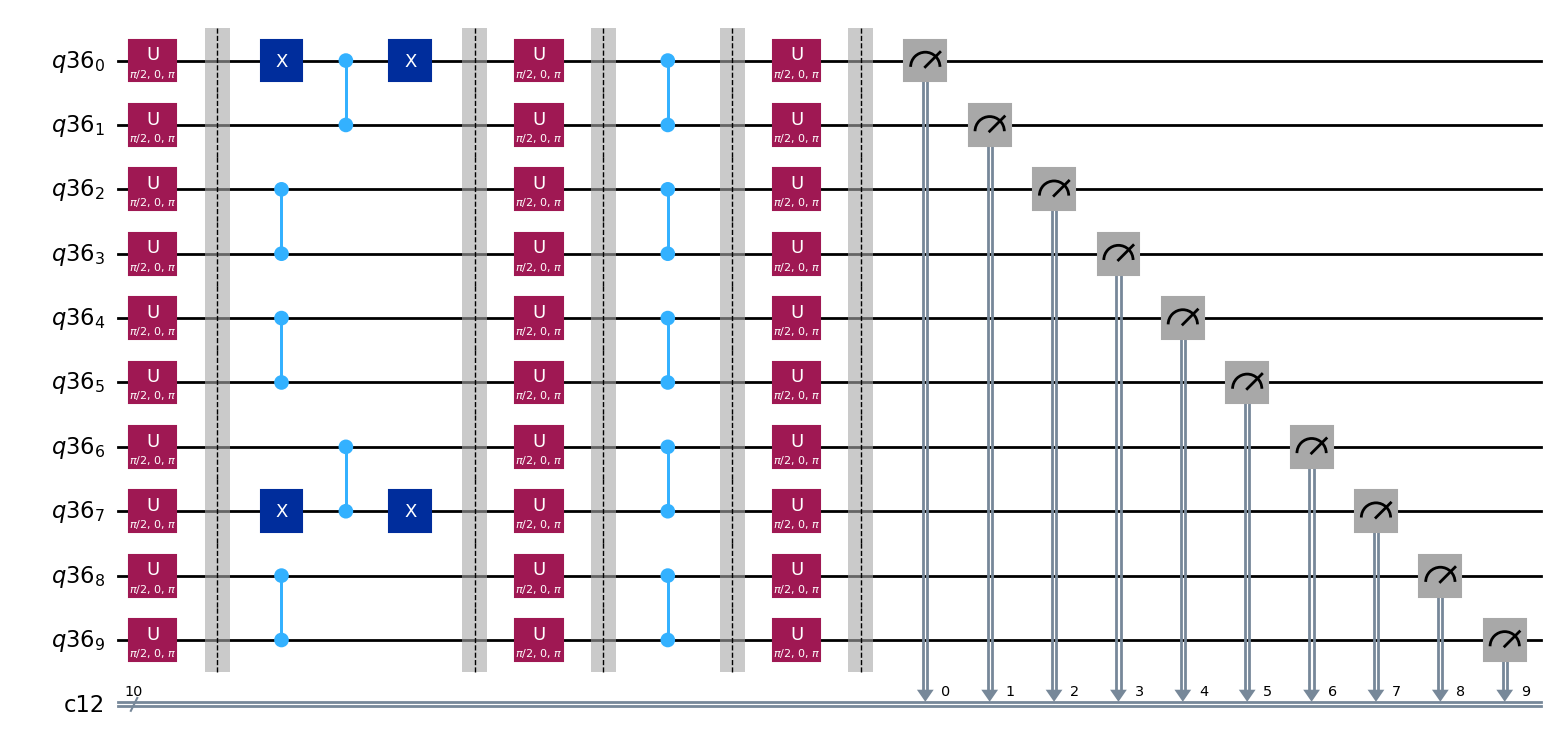

In [11]:
# Visualize the first circuit for each qubit size.
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        qc = circuits[num_qubits][circuit_id]
        print(f"Number of Qubits: {num_qubits}")
        display(qc.draw(output='mpl'))
        break